In [6]:
import pandas as pd
import polars as pl
import seaborn as sns
from pathlib import Path
from tbparse import SummaryReader
base_dir = Path("/Users/morton/VSCode/operators/design/simulation/study-6")
measure = "Accuracies/g"
n_subj = 4

In [7]:
raw_dfs = []
for number in range(1, n_subj + 1):
    subject = f"{number:03d}"
    if number % 2 == 0:
        condition = "AL"
    else:
        condition = "PI"
    for design in ["0", "1"]:
        reader = SummaryReader(str(base_dir / f"sub-{subject}" / f"design-{design}"))
        raw = (
            pl.DataFrame(reader.scalars)
            .with_columns(
                subject=pl.lit(subject),
                condition=pl.lit(condition),
                design=pl.lit(design),
                run=pl.col("value").cum_count().over(pl.col("step")),
            )
            .with_columns(
                smooth_value=pl.col("value").rolling_mean(window_size=50).over("tag", "run"),
            )
        )
        raw_dfs.append(raw)
df = pl.concat(raw_dfs)

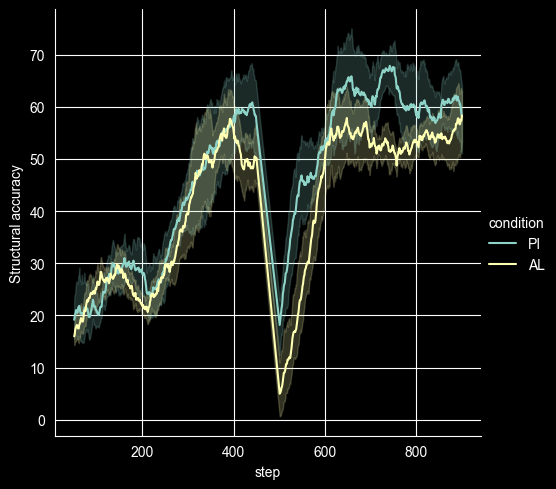

In [8]:
g = sns.relplot(
    df.filter(pl.col("tag") == "Accuracies/g"),
    x="step",
    y="smooth_value",
    kind="line",
    hue="condition",
)
g.set(ylabel="Structural accuracy")

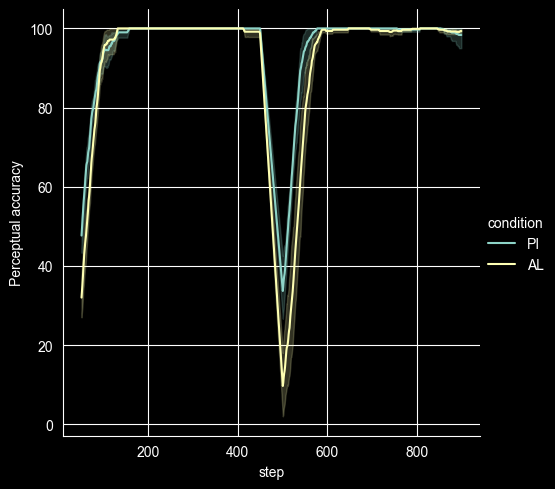

In [9]:
g = sns.relplot(
    df.filter(pl.col("tag") == "Accuracies/p"),
    x="step",
    y="smooth_value",
    kind="line",
    hue="condition",
)
g.set(ylabel="Perceptual accuracy")